# 0. Message to Teammates

This notebook contains the code we will use to develop and train the **TinyML weather prediction model** for our capstone project.

I added explanations throughout the notebook so that everyone on the team can follow the development process, even without prior experience in machine learning, TensorFlow, or Python. Each major section explains **what we are doing, why we are doing it, and how it contributes to the final weather prediction device**.

The overall process will involve collecting historical weather data, preparing and analyzing the data, training and evaluating a machine learning model, and eventually converting the trained model so that it can run directly on our **ESP32**.

Please feel free to experiment with the notebook and contribute. If something is unfamiliar, then the explanations here, along with online resources, YouTube, and AI tools, can be used to learn more about each step.

The goal is for this notebook to document not only the final model, but also **how we developed it and the engineering decisions we made along the way (especially to showcase to the TA/Professor).**

## 1. Setting Up the Python Environment

Before working with the weather data, we have to load the Python libraries that will be used throughout the project.

- **TensorFlow** — Used to create and train the machine learning model.
- **Pandas** — Used to organize and manipulate weather data in tables.
- **NumPy** — Used for numerical calculations and arrays.
- **Matplotlib** — Used to create graphs and visualize the weather data.
- **Scikit-learn** — Provides useful tools for preparing data and evaluating the model.

The code below also prints the version of each library. This helps us make sure everyone on the team is using compatible software versions.

The GPU check tells us whether TensorFlow can use a dedicated graphics card. A GPU is not required for this project because our TinyML model will be relatively small and is ultimately designed to run on an ESP32. (so... just don't worry about it, its just a checker for me)

In [8]:
# Import dependencies and libraries
import sys
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib
import sklearn

# Validation check to see if versions match up
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU")) 

# NOTE: Do not worry if GPU list is empty, the TinyML model is going to be small enough to run on a CPU instead of needing a GPU anyway


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
TensorFlow: 2.21.0
Pandas: 3.0.6
NumPy: 2.4.6
scikit-learn: 1.9.1
GPUs: []


## 2. Downloading Historical Weather Data

Before our physical weather sensors are available, we need real weather measurements that we can use to develop and train the machine learning model.

For our initial dataset, we are downloading historical observations from **University Park Airport (UNV)**. These observations contain measurements similar to what our final ESP32 weather device will collect, including temperature, humidity, and atmospheric pressure.

We are downloading approximately **2015–2025** so the model will eventually have several years of different seasons and weather conditions to learn from.

The basic process is:

**Iowa Environmental Mesonet → Request UNV weather observations → Download data → Save as a CSV file**

A **CSV file** is essentially a spreadsheet stored as a text file. Each row represents a weather observation and each column represents a measurement such as temperature or wind speed.

The code also checks whether we already downloaded the file. If it exists, it skips the download so we do not download the same 26 MB dataset every time the notebook runs.

In [ ]:
import requests
from pathlib import Path

STATION = "UNV"          # University Park Airport (KUNV)
START = "2015-01-01T00:00:00Z"
END   = "2026-01-01T00:00:00Z"

raw_path = Path("../data/raw/UNV_asos_2015_2025.csv")   # ../ because the notebook lives in notebooks/

url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"

# Tell the weather database which station and time period we want
params = {
    "station": STATION,
    "data": "all",
    "sts": START,
    "ets": END,
    "tz": "Etc/UTC",
    "format": "onlycomma",
    "missing": "empty",
    "trace": "empty",
    "report_type": [3, 4],
}

# Only downloads the dataset if it is not already saved on this computer
if raw_path.exists():
    print("Already downloaded, skipping.")
else:
    r = requests.get(url, params=params, timeout=300)
    r.raise_for_status()
    raw_path.write_bytes(r.content)
    print(f"Saved {raw_path} ({raw_path.stat().st_size / 1e6:.1f} MB)")

Already downloaded, skipping.


## 3. Loading the Weather Data

The historical weather observations are currently stored in a CSV file on the computer.

Pandas loads this file into something called a **DataFrame**. A DataFrame can be thought of as a spreadsheet inside Python:

- Each **row** represents one weather observation.
- Each **column** represents a variable such as temperature, humidity, pressure, or wind speed.

After loading the file, we check its size and display the first few observations to make sure the data loaded correctly.

In [13]:
import pandas as pd

df = pd.read_csv(raw_path, low_memory=False)

print("Number of weather observations:", df.shape[0])
print("Number of available variables:", df.shape[1])
print(df.shape)

df.head()

Number of weather observations: 159315
Number of available variables: 30
(159315, 30)


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,UNV,2015-01-01 00:53,17.60,3.20,52.60,240.0,8.0,0.0,30.14,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.37,KUNV 010053Z 24008KT 10SM SKC M08/M16 A3014,NaN
1,UNV,2015-01-01 01:53,19.40,3.20,48.69,220.0,7.0,0.0,30.12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.42,KUNV 010153Z 22007KT 10SM SKC M07/M16 A3012,NaN
2,UNV,2015-01-01 02:55,19.58,4.82,52.05,220.0,8.0,0.0,30.12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.81,KUNV 010255Z AUTO 22008KT 10SM M07/M15 A3012 R...,NaN
3,UNV,2015-01-01 03:15,20.30,5.00,50.90,230.0,11.0,0.0,30.12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.68,KUNV 010315Z AUTO 23011G14KT 10SM CLR M06/M15 ...,NaN
4,UNV,2015-01-01 03:35,20.66,5.18,50.54,240.0,13.0,0.0,30.12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.04,KUNV 010335Z AUTO 24013G18KT 10SM CLR M06/M15 ...,NaN


### Previewing the Dataset

Below are the first few weather observations in the dataset.

Some important columns include:

| Column | Meaning |
|---|---|
| `valid` | Date and time of the observation |
| `tmpf` | Air temperature in °F |
| `dwpf` | Dew point temperature in °F |
| `relh` | Relative humidity (%) |
| `drct` | Wind direction in degrees |
| `sknt` | Wind speed in knots |
| `p01i` | Precipitation |
| `alti` | Atmospheric pressure (altimeter setting) |

Not every available measurement will necessarily be used by our machine learning model. Later, we will select the measurements that are useful and that can realistically be measured by our ESP32 weather station.

`NaN` means that a particular measurement was not available for that observation. We will handle missing measurements during the data cleaning process when we get to it.

## 4. Inspecting the Available Measurements

Before deciding what information the machine learning model should use, we need to understand what measurements are available in the dataset.

The following command displays the names of all columns provided by the weather database.

This allows us to compare the historical dataset with the sensors planned for our physical weather station and decide which measurements should become inputs to the TinyML model.

In [11]:
print(df.columns.tolist())

['station', 'valid', 'tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'p01i', 'alti', 'mslp', 'vsby', 'gust', 'skyc1', 'skyc2', 'skyc3', 'skyc4', 'skyl1', 'skyl2', 'skyl3', 'skyl4', 'wxcodes', 'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr', 'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time', 'feel', 'metar', 'snowdepth']


In [ ]:
# CSV files store dates as plain text. If we want Pandas to do time math (i.e gaps, resamping, shifting) later, 
# then we have to convert it to real datetimes

df["valid"] = pd.to_datetime(df["valid"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159315 entries, 0 to 159314
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   station            159315 non-null  str           
 1   valid              159315 non-null  datetime64[us]
 2   tmpf               159058 non-null  float64       
 3   dwpf               159042 non-null  float64       
 4   relh               158956 non-null  float64       
 5   drct               157399 non-null  float64       
 6   sknt               158471 non-null  float64       
 7   p01i               159303 non-null  float64       
 8   alti               159107 non-null  float64       
 9   mslp               0 non-null       float64       
 10  vsby               158828 non-null  float64       
 11  gust               20926 non-null   float64       
 12  skyc1              155737 non-null  str           
 13  skyc2              51136 non-null   str           
 14 

In [ ]:
# This tells us how much data is missing by printing the percent of missing values per column
cols = ["tmpf", "dwpf", "relh", "alti", "mslp", "p01i", "vsby", "skyc1", "wxcodes"]
(df[cols].isna().mean() * 100).round(1)

tmpf         0.2
dwpf         0.2
relh         0.2
alti         0.1
mslp       100.0
p01i         0.0
vsby         0.3
skyc1        2.2
wxcodes     80.2
dtype: float64

In [16]:
# Shows whether the reporting frequency changed over time, which would affect how we resample
df.groupby(df["valid"].dt.year).size()

valid
2015    14602
2016    15031
2017    14704
2018    13947
2019    15076
2020    13964
2021    14343
2022    15002
2023    14548
2024    13673
2025    14425
dtype: int64

In [17]:
# Time gaps between observations

gap_min = df["valid"].diff().dt.total_seconds() / 60 # Common spacings in minutes
print(gap_min.round().value_counts().head(10)) # Counts large outages
print("Gaps longer than 6 hours:", (gap_min > 360).sum())

valid
20.0    72781
60.0    58862
18.0     4579
19.0     3412
22.0     2821
21.0     2394
23.0     1125
17.0      661
82.0      561
25.0      536
Name: count, dtype: int64
Gaps longer than 6 hours: 127


In [ ]:
# Sanity checking the values, since the IEM does little quality control we have to do it ourselves
# Looks for bad sensor readings like humidity above 100, or a temperature at a crazy value like -80 degrees F
df[["tmpf", "dwpf", "relh", "alti", "mslp", "p01i", "vsby"]].describe()

,tmpf,dwpf,relh,alti,mslp,p01i,vsby
count,159058.000000,159042.000000,158956.000000,159107.000000,0.0,159303.000000,158828.000000
mean,50.009482,41.308917,74.511822,30.037757,NaN,0.001229,8.898373
std,17.768511,18.767084,19.388642,0.216909,NaN,0.013395,2.500094
min,-11.380000,-22.000000,11.240000,20.120000,NaN,0.000000,0.000000
25%,35.600000,26.600000,60.760000,29.910000,NaN,0.000000,10.000000
50%,51.000000,42.600000,75.510000,30.040000,NaN,0.000000,10.000000
75%,64.580000,57.400000,92.860000,30.180000,NaN,0.000000,10.000000
max,95.000000,80.600000,100.000000,39.840000,NaN,0.870000,76.000000


In [19]:
# Lists the most common present weather codes.
# RA is rain
# SN is snow
# - means light
# + means heavy
# BR is mist
# FG is fog
# TS is thunderstorm

# We're gonna use these to build the "Rain" label, and this tells us how common each type is
df["wxcodes"].value_counts().head(15)

wxcodes
BR        7842
-SN       4724
-RA       3363
RA        2652
FG        2424
-DZ       1648
DZ        1162
-RA BR    1094
VCSH       909
RA BR      734
HZ         658
-DZ BR     513
VCTS       364
+RA        353
UP         295
Name: count, dtype: int64

## 5. Clean and label the Data

In [20]:
# Drops empty columns, converts pressure, and finds the bad values

core = ["valid", "tmpf", "dwpf", "relh", "alti", "wxcodes", "skyc1"]
d = df[core].copy()

d["pressure_hpa"] = d["alti"] * 33.8639      # inHg -> hPa, the unit our sensor will use

bad = d[(d["alti"] < 28.5) | (d["alti"] > 31.5)]
print("Suspicious pressure rows:", len(bad))
bad[["valid", "alti"]].head(10)

Suspicious pressure rows: 11


,valid,alti
18629,2016-04-08 16:53:00,27.90
23823,2016-08-13 17:40:00,26.69
27946,2016-11-20 10:53:00,27.95
28483,2016-12-03 18:53:00,20.12
53323,2018-08-16 18:53:00,20.12
58643,2019-01-11 18:53:00,20.29
63585,2019-05-10 14:53:00,22.97
81211,2020-07-27 19:53:00,39.84
84955,2020-11-01 18:05:00,39.71
92042,2021-05-05 10:26:00,26.70


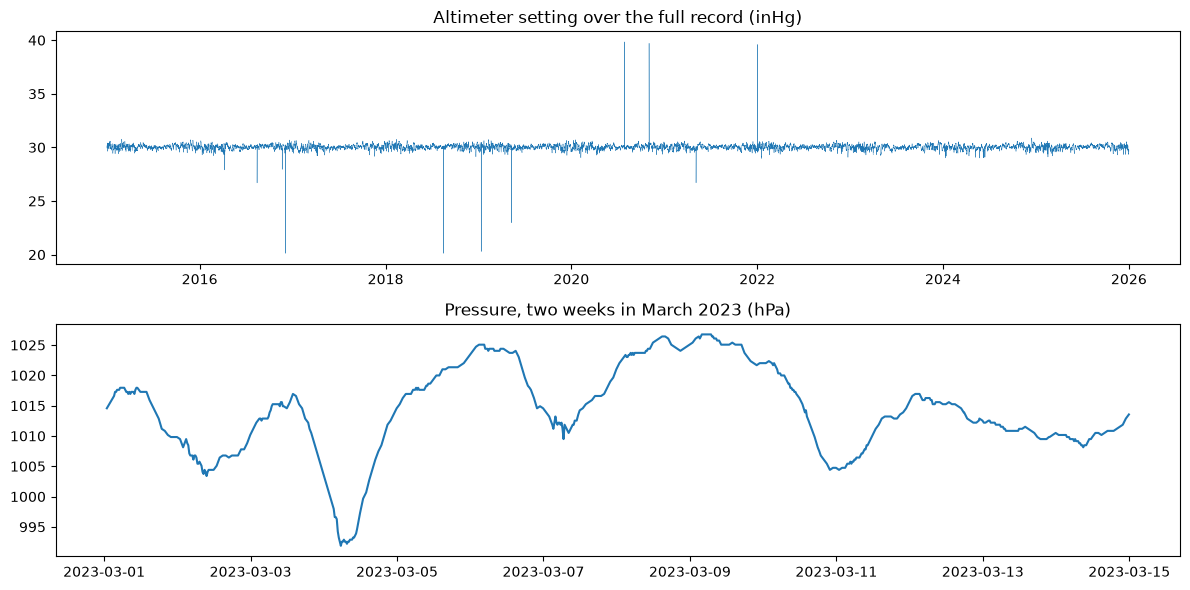

In [21]:
# Creates two plots to visualize the data to see where bad values lie

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(d["valid"], d["alti"], linewidth=0.3)
ax[0].set_title("Altimeter setting over the full record (inHg)")
sub = d[(d["valid"] >= "2023-03-01") & (d["valid"] < "2023-03-15")]
ax[1].plot(sub["valid"], sub["pressure_hpa"])
ax[1].set_title("Pressure, two weeks in March 2023 (hPa)")
plt.tight_layout()
plt.show()

In [22]:
# Creates a precipitation flag from wxcodes, so any type of precipitation like snow, rain, thunderstorms, etc will flag as generic precipitation for now
PRECIP = ("RA", "DZ", "SN", "SG", "PL", "GR", "GS", "UP", "SH", "TS")

def has_precip(w):
    if not isinstance(w, str):          # blank = nothing reported
        return False
    for tok in w.split():
        tok = tok.lstrip("+-")          # drop intensity marks
        if tok.startswith("VC"):        # "in the vicinity" -> not at the station
            continue
        if any(code in tok for code in PRECIP):
            return True
    return False

d["precip_now"] = d["wxcodes"].apply(has_precip)

print("Fraction of observations with precipitation:", d["precip_now"].mean().round(3))
print(d.groupby(d["valid"].dt.month)["precip_now"].mean().round(3))

Fraction of observations with precipitation: 0.116
valid
1     0.189
2     0.180
3     0.139
4     0.132
5     0.121
6     0.083
7     0.062
8     0.055
9     0.083
10    0.094
11    0.096
12    0.161
Name: precip_now, dtype: float64
